# Dataset

This notebook checks that the precomputed SHARP Doppler traces are available under `data/doppler_traces`. If the folder is missing, it downloads `doppler_traces.zip` from Google Drive and extracts it into the expected layout.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from wifi_doppler.data.download import ensure_doppler_traces

DOPPLER_DIR = ensure_doppler_traces(PROJECT_ROOT / "data")

Doppler traces already available: C:\Users\gianm\Development\wifi-doppler-har\data\doppler_traces


(18766, 100)


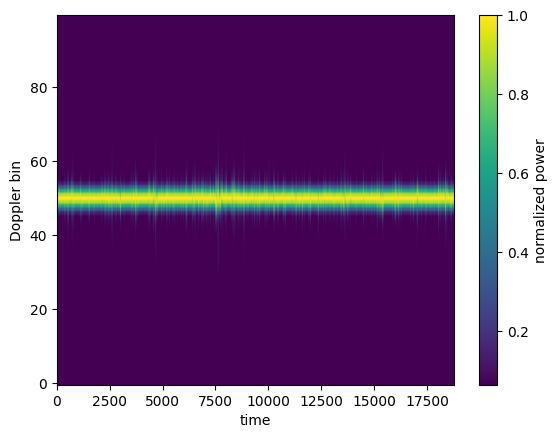

In [2]:
import pickle
import matplotlib.pyplot as plt

path = DOPPLER_DIR / "S1a" / "S1a_C_stream_0.txt"

with open(path, "rb") as f:
    trace = pickle.load(f)

print(trace.shape)

plt.imshow(trace.T, aspect="auto", origin="lower", cmap="viridis")
plt.xlabel("time")
plt.ylabel("Doppler bin")
plt.colorbar(label="normalized power")
plt.show()

In [3]:
from torch import no_grad

def eval_fused(model, dataloader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    sum_correct = 0
    sharp_correct = 0
    total = 0

    with no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            sum_logits = model(x, fusion="sum")
            sharp_logits = model(x, fusion="sharp")

            batch_loss = loss_fn(sum_logits, y)

            total_loss += batch_loss.item() * x.size(0)
            sum_correct += (sum_logits.argmax(dim=1) == y).sum().item()
            sharp_correct += (sharp_logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    return {
        "loss": total_loss / total,
        "sum_acc": sum_correct / total,
        "sharp_acc": sharp_correct / total,
    }

# Training

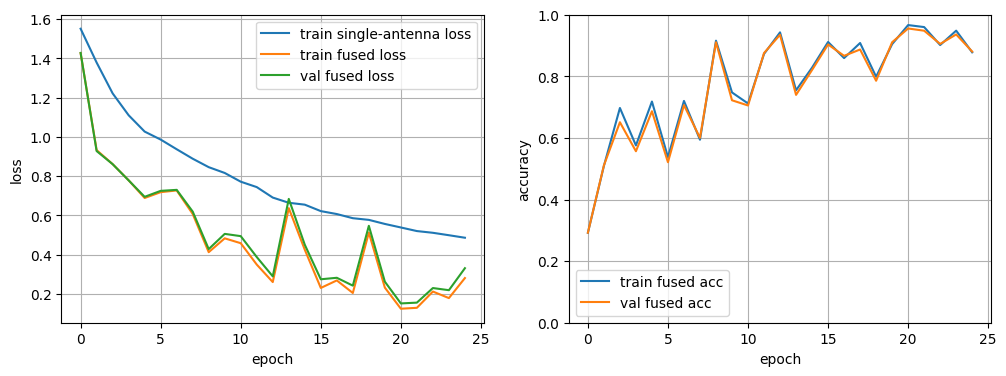

epoch: 025
  train_loss      : 0.4856
  train_sum_acc   : 0.8698
  train_sharp_acc : 0.8779
  val_sum_acc     : 0.8810
  val_sharp_acc   : 0.8804
  best_val_acc    : 0.9553 @ epoch 21


In [ ]:
import torch
from torch.cuda import is_available
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
import copy

from wifi_doppler.models.base_model import MultiAntennaModel, SingleAntennaModel
from wifi_doppler.data.dataset import DopplerWindowDataset

EPOCHS = 25

device = "cuda" if is_available() else "cpu"

single_antenna_model = SingleAntennaModel().to(device)
model = MultiAntennaModel(single_antenna_model).to(device)

# Materialize LazyLinear before optimizer creation
with no_grad():
    dummy = torch.zeros(1, 4, 340, 100, device=device)
    _ = model.forward_antennas(dummy)

print(sum(p.numel() for p in single_antenna_model.parameters()))

optimizer = Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    eps=1e-7,
    weight_decay=0.0,
)

model.to(device)

loss = CrossEntropyLoss()

train_dataset = DopplerWindowDataset(DOPPLER_DIR, split=(0, 0.6))
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = DopplerWindowDataset(DOPPLER_DIR, split=(0.6, 0.8))
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

best_val_acc = 0.0
best_epoch = -1
best_state = None

history = {
    "train_loss": [],
    "train_fused_loss": [],
    "val_fused_loss": [],
    "train_fused_acc": [],
    "val_fused_acc": [],
}

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    total_steps = 0

    for x, y in train_dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model.forward_antennas(x) # (batch_size, num_antennas, num_classes)
        out = logits.reshape(-1, logits.size(-1)) # (batch_size * num_antennas, num_classes)
        target = y.repeat_interleave(x.size(1)) # (batch_size) -> (batch_size * num_antennas)

        train_loss = loss(out, target)
        train_loss.backward()
        optimizer.step()

        running_loss += train_loss.item()
        total_steps += 1

    epoch_train_loss = running_loss / total_steps

    train_metrics = eval_fused(model, train_dataloader, loss, device)
    val_metrics = eval_fused(model, val_dataloader, loss, device)

    history["train_loss"].append(epoch_train_loss)
    history["train_fused_loss"].append(train_metrics["loss"])
    history["val_fused_loss"].append(val_metrics["loss"])

    history["train_fused_acc"].append(train_metrics["sharp_acc"])
    history["val_fused_acc"].append(val_metrics["sharp_acc"])

    if val_metrics["sharp_acc"] > best_val_acc:
        best_val_acc = val_metrics["sharp_acc"]
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model.state_dict())


    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train single-antenna loss")
    axes[0].plot(history["train_fused_loss"], label="train fused loss")
    axes[0].plot(history["val_fused_loss"], label="val fused loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history["train_fused_acc"], label="train fused acc")
    axes[1].plot(history["val_fused_acc"], label="val fused acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.show()

    print(
        f"epoch: {epoch + 1:03d}\n"
        f"  train_loss      : {epoch_train_loss:.4f}\n"
        f"  train_sum_acc   : {train_metrics['sum_acc']:.4f}\n"
        f"  train_sharp_acc : {train_metrics['sharp_acc']:.4f}\n"
        f"  val_sum_acc     : {val_metrics['sum_acc']:.4f}\n"
        f"  val_sharp_acc   : {val_metrics['sharp_acc']:.4f}\n"
        f"  best_val_acc    : {best_val_acc:.4f} @ epoch {best_epoch}"
    )